<a href="https://colab.research.google.com/github/GermanAlmanza14/Econometria_con_Python/blob/main/BWGHT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### License: Creative Commons Attribution 4.0 International (CC BY 4.0)
This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).
<br>
© 2025 Germán Almanza ralmanza@uacj.mx


# **Prueba de restricción lineal multiple: estadístico-F**

Comenzamos instalando el paquete ```wooldridge``` en Colab.

In [ ]:
!pip install wooldridge

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 28.7 MB/s eta 0:00:00


In [ ]:
import wooldridge as woo
import numpy as np
import statsmodels.formula.api as smf
import scipy.stats as sts

bwght = woo.dataWoo('bwght')
bwght

,faminc,cigtax,cigprice,bwght,fatheduc,motheduc,parity,male,white,cigs,lbwght,bwghtlbs,packs,lfaminc
0,13.5,16.5,122.300003,109,12.0,12.0,1,1,1,0,4.691348,6.8125,0.0,2.602690
1,7.5,16.5,122.300003,133,6.0,12.0,2,1,0,0,4.890349,8.3125,0.0,2.014903
2,0.5,16.5,122.300003,129,NaN,12.0,2,0,0,0,4.859812,8.0625,0.0,-0.693147
3,15.5,16.5,122.300003,126,12.0,12.0,2,1,0,0,4.836282,7.8750,0.0,2.740840
4,27.5,16.5,122.300003,134,14.0,12.0,2,1,1,0,4.897840,8.3750,0.0,3.314186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1383,27.5,30.0,138.300003,110,12.0,12.0,4,1,1,0,4.700480,6.8750,0.0,3.314186
1384,5.5,30.0,138.300003,146,NaN,16.0,2,1,1,0,4.983607,9.1250,0.0,1.704748
1385,65.0,8.0,118.599998,135,18.0,16.0,2,0,1,0,4.905275,8.4375,0.0,4.174387
1386,27.5,8.0,118.599998,118,NaN,14.0,2,0,1,0,4.770685,7.3750,0.0,3.314186


# **Regresión 1 (modelo NO restringido)**

<br>



<br>



En el siguiente ejemplo se plantea un modelo que explica el peso de recien nacidos. Estudios clínicos sugieren que la ingesta de cigarros durante el embarazo tiene un efecto negativo en el peso de los recien nacidos, se agregan otras variables para analizar su impacto.



**Variables:**

* *bwght*: Peso al momento de nacer (oz),

* *cigs*: promedio de cigarros que la madre fumó al día durante el embarazo,

* *parity*: orden de nacimiento del niño,

* *faminc*: ingreso anual en el hogar,

* *motheduc*: años de educación de la madre,

* *fatheduc*: años de educación del padre.

<br>

**Modelo**

$$bwght=\beta_0+\beta_1\; cigs+\beta_2\; parity+\beta_3\; faminc+\beta_4\; motheduc+\beta_5\;  fatheduc+u\qquad(\clubsuit)$$

<br>

El modelo anterior pretende describir el impacto de estas variables en el salario de los jugadores. Sin embargo, no existen estudios previos que señalen que la educación de los padres influye en el peso de sus hijos al momento de nacer, observemos que resultado tienen estas variables en la regresión.

<br>


In [ ]:
# regresion OLS: no-restringida
reg_nr = smf.ols(
    formula='bwght ~ cigs + parity + faminc + motheduc + fatheduc',
    data=bwght).fit()
reg_nr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  bwght   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     9.553
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           5.99e-09
Time:                        16:50:59   Log-Likelihood:                -5242.2
No. Observations:                1191   AIC:                         1.050e+04
Df Residuals:                    1185   BIC:                         1.053e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    114.5243      3.728     30.716      0.000     107.209     121.839
cigs          -0.5959      0.110     -5.401      0.000      -0.812      -0.379
parity         1.7876      0.659      2.711      0.007       0.494       3.081
faminc         0.0560      0.037      1.533      0.126      -0.016       0.128
motheduc      -0.3705      0.320     -1.158      0.247      -0.998       0.257
fatheduc       0.4724      0.283      1.671      0.095      -0.082       1.027
==============================================================================
Omnibus:                      120.762   Durbin-Watson:                   1.938
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              838.114
Skew:                          -0.119   Prob(JB):                    1.01e-182
Kurtosis:                       7.103   Cond. No.                         266.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### **Resultado de la regresión 1 (modelo NO restringido):**


El resultado de la regresión señala que <mark>el ingreso familiar (*faminc*) y el peso de los padres (*motheduc* y *fatheduc*) son estadísticamente no significativo.</mark> Las variables significativas tienen la siguiente interpretación:

* *cigs*: por cada cigarro que fuma la madre durante el embarazo, el peso del recien nacido disminuye aproximadamente en $0.59$ oz.

* *parity*: por cada hijo previo al que esta por nacer, el nuevo hijo gana aproximadamente 1.78 oz. en comparación con el peso del hijo anterior.


<br>

Antes de despreciar estas variables, verificaremos si existe una alta correlación entre éstas, que este ocacionando problemas de **multicolinealidad imperfecta**.


## **Matriz de correlación: triangular inferior**


Para esto introducimos una función de `numpy` llamada `.triu` (triangular upper).

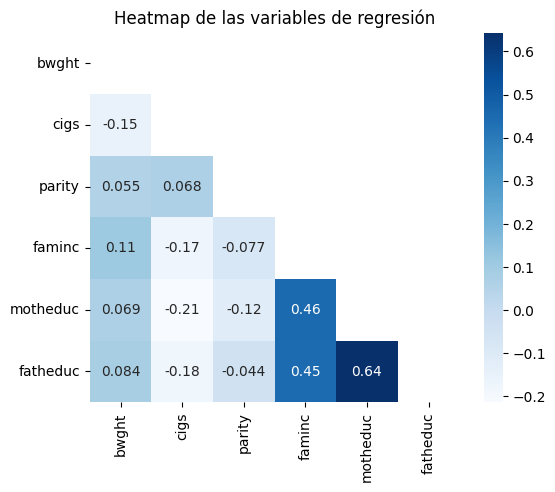

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


variables=bwght[['bwght','cigs','parity','faminc','motheduc','fatheduc']]
corr_var=variables.corr()

mask = np.triu(np.ones_like(corr_var, dtype=bool))
sns.heatmap(corr_var, mask=mask, annot=True, cmap='Blues',square=True)
plt.title('Heatmap de las variables de regresión')
plt.show()

### **No existe multicolinealidad**

La matriz de correlación muestra una baja correlación entre las variables explicativas, por lo tanto, <mark>podemos intuir que la educación de los padres son variables son variables mutuamente no significativas.</mark> Probaremos esto con **una prueba de hipótesis conjunta** y el estadístico-F.



# **Regresión 2 (modelo restringido)**

<br>

Hacemos la regresión eliminando de la ecuación $(\clubsuit)$ únicamente las variables de educación de los padres, de modo que el modelo restringido es

$$bwght=\beta_0+\beta_1\; cigs+\beta_2\; parity+\beta_3\; faminc+u$$



<br>

In [ ]:
# regresion OLS: no-restringida ESPURIO obs=1388
reg_r0 = smf.ols(formula='bwght ~ cigs + parity + faminc',data=bwght).fit()
reg_r0.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  bwght   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     16.63
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           1.28e-10
Time:                        16:51:00   Log-Likelihood:                -6126.8
No. Observations:                1388   AIC:                         1.226e+04
Df Residuals:                    1384   BIC:                         1.228e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    114.2143      1.469     77.734      0.000     111.332     117.097
cigs          -0.4772      0.092     -5.214      0.000      -0.657      -0.298
parity         1.6164      0.604      2.676      0.008       0.432       2.801
faminc         0.0979      0.029      3.355      0.001       0.041       0.155
==============================================================================
Omnibus:                      118.381   Durbin-Watson:                   1.922
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              638.175
Skew:                          -0.156   Prob(JB):                    2.64e-139
Kurtosis:                       6.307   Cond. No.                         98.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## **Distinto número de observaciones.**


En el resultado de la regresión anterior, se muestra que el número de observaciones es 1388, que difiere del número de observaciones 1191 en el modelo no restringido. Esto es porque seguramente falta información en las variables *motheduc* y *fatheduc*. Para verificar esto, utilizaremos las funciones `.isnull()` y `.sum()` para identificar el número de celdas que hacen falta con información.

In [ ]:
bwght[['bwght','cigs','parity','faminc','motheduc','fatheduc']].isnull().sum()

,0
bwght,0
cigs,0
parity,0
faminc,0
motheduc,1
fatheduc,196


### **Observaciones faltantes.**

Se tiene que en esta base de datos las variables de educación de los padres hace falta 197 observaciones (entre estas dos variables), por lo tanto, en el modelo restringido debemos eliminar estas observaciones. De no hacerlo, tendríamos un estadistico-F espurio.

Es muy importante eliminar únicamente las observaciones que no tienen información en las variables señaladas. En el modelo NO restringido `python` eliminó estas observaciones en automático. En el modelo restringido es necesario eliminarlas manualmente.

## **Eliminar filas con datos nulos (NaN/None)**


Borrar observaciones nulas de una base de datos, hay diferentes maneras de hacerlo.

* `.dopna()` elimina todas las observaciones en la base de datos,

También podemos crear un subconjunto o sub-base de datos (en este caso definimos `bwght_nan`) para eliminar los valores nulos de las variables que estamos trabajando y preservar la base de datos original.

***

In [ ]:
bwght_n=bwght[['bwght','cigs','parity','faminc','motheduc','fatheduc']]
bwght_nan=bwght_n.dropna()
bwght_nan


,bwght,cigs,parity,faminc,motheduc,fatheduc
0,109,0,1,13.5,12.0,12.0
1,133,0,2,7.5,12.0,6.0
3,126,0,2,15.5,12.0,12.0
4,134,0,2,27.5,12.0,14.0
5,118,0,6,7.5,14.0,12.0
...,...,...,...,...,...,...
1381,87,0,1,12.5,12.0,14.0
1382,135,0,3,22.5,16.0,16.0
1383,110,0,4,27.5,12.0,12.0
1385,135,0,2,65.0,16.0,18.0


### **bwght_nan**

Hemos creado la sub-base de datos **bwght_nan** en donde eliminamos las observaciones que carecen de valor en las variables de educación de los padres. Esta base de datos es la que vamos a utilizar en el modelo restringido.

# **Regresión del modelo restringido: 'bwght_nan'**

In [ ]:
reg_r2 = smf.ols(formula='bwght ~ cigs + parity + faminc',data=bwght_nan).fit()
reg_r2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  bwght   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     14.95
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           1.47e-09
Time:                        16:51:01   Log-Likelihood:                -5243.7
No. Observations:                1191   AIC:                         1.050e+04
Df Residuals:                    1187   BIC:                         1.052e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    115.4699      1.656     69.733      0.000     112.221     118.719
cigs          -0.5979      0.109     -5.496      0.000      -0.811      -0.384
parity         1.8323      0.658      2.787      0.005       0.542       3.122
faminc         0.0671      0.032      2.070      0.039       0.004       0.131
==============================================================================
Omnibus:                      119.243   Durbin-Watson:                   1.940
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              813.708
Skew:                          -0.117   Prob(JB):                    2.02e-177
Kurtosis:                       7.043   Cond. No.                         111.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# **Prueba de hipótesis conjunta: estadístico-F**


Queremos verificar que la educación de los padres es conjuntamente no significativa, por lo tanto plantearemos la siguiente hipóteisis.

<br>


## **Hipótesis múltiple**


$$H_0:\;\beta_4=\beta_5=0.$$


La hipótesis alternativa  es

$$H_1:\;¡H_0\;\text{NO es verdadera!}.$$


En realidad <mark>buscamos evidencia estadística para no rechazar $H_0$.</mark>


### **Estadísticos de los modelos no restringido y restringido.**


Vamos a utilizar el estadístico-F en términos de las $R^2$ de cada regresión

In [ ]:
#    Estadisticos de interes modelo NO restringido
# R^2
R2_nr=reg_nr.rsquared
#  Grados de libertad_nr
gl_nr=reg_nr.df_resid

print(f"Modelo NO restringido, R-cuadrado: {R2_nr:.4f}")
print(f"Modelo NO restringido,  gl_nr: {gl_nr:.0f}")

#    Estadisticos de interes modelo restringido
# R^2
R2_r=reg_r2.rsquared
#  Grados de libertad_r
gl_r=reg_r2.df_resid
print(f"Modelo restringido, R-cuadrado: {R2_r:.4f}")
print(f"Modelo restringido,  gl_r: {gl_r:.0f}")

#  Valor q=reg_r.df_resid - reg_nr.df_resid
q=reg_r2.df_resid-reg_nr.df_resid
print(f"Diferencia de los grados de libertad (valor q): {q:.0f}")



Modelo NO restringido, R-cuadrado: 0.0387
Modelo NO restringido,  gl_nr: 1185
Modelo restringido, R-cuadrado: 0.0364
Modelo restringido,  gl_r: 1187
Diferencia de los grados de libertad (valor q): 2


## **Código del estadístico-F: ANOVA**

In [ ]:
import statsmodels.api as sm
import statsmodels.stats as ss


ss.anova.anova_lm(reg_r2, reg_nr)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,1187.0,465166.792127,0.0,NaN,NaN,NaN
1,1185.0,464041.135130,2.0,1125.656997,1.437269,0.23799


In [ ]:
import statsmodels.api as sm

print(reg_nr.f_test(['motheduc','fatheduc']))

<F test: F=1.43726863897517, p=0.23798962194786966, df_denom=1.18e+03, df_num=2>


## **Estadístico-F: con valores de $R^2$**


$$F=\frac{(R^2_{nr}-R^2_{r})/q}{(1-R^2_{nr})/gl_{nr}}.$$


<br>

## **Significancia general de la regresión**

$$F=\frac{R^2/k}{(1-R^2)/(n-k-1)}.$$



In [ ]:
F_estR=(R2_nr-R2_r)/(1-R2_nr)*(gl_nr)/(q)
print(f"F= ({R2_nr:.3f}-{R2_r:.3f})/(1-{R2_nr:.3f})*({gl_nr:.0f})/{q:.0f} = {F_estR:.3f}")
print(f'El estadístico F con valores de R^2={F_estR:.3f}')
p_value=1-sts.f.cdf(F_estR, q, gl_nr)
print(f'p-value del Estadístico-F: {p_value:.4f}\n')


k=reg_nr.df_model
F_estSGR=(R2_nr)/(1-R2_nr)*(gl_nr)/(k)
print(f"F= ({R2_nr:.3f})/(1-{R2_nr:.3f})*({gl_nr:.0f})/{k:.0f} = {F_estSGR:.3f}")
print(f'Significancia de la regresión (nr) estadístico F={F_estSGR:.3f}')
p_value_SGR=1-sts.f.cdf(F_estSGR, k, gl_nr)
print(f'p-value de la significancia de la regresión {p_value_SGR:.4f}')


F= (0.039-0.036)/(1-0.039)*(1185)/2 = 1.437
El estadístico F con valores de R^2=1.437
p-value del Estadístico-F: 0.2380

F= (0.039)/(1-0.039)*(1185)/5 = 9.553
Significancia de la regresión (nr) estadístico F=9.553
p-value de la significancia de la regresión 0.0000


### **F-Test: verificación**

In [ ]:
import scipy.stats as sts

alpha=.99
nu1=q
nu2=gl_nr

F_val=sts.f.ppf(alpha,nu1,nu2)
print(f'F-value({alpha:.2f},{nu1:.0f},{nu2:.0f})= {F_val:.4f}')

p_value=1-sts.f.cdf(F_estR, q, gl_nr)
print(f'p-value: {p_value:.4f} del estadístico-F:{F_estR:.3f}')
signif=1-alpha
SIG=signif*100

print(f'nivel de significancia (1-alpha)={signif:.4}')

if p_value < signif:
    print('Dado que p-value< nivel de significancia, se rechaza H0:')
    print(f'las variables son conjuntamente significativas al {signif:.4}%.')
else:
    print('Dado que p-value> nivel de significancia,\n NO se rechaza H0: ¡Las variables son conjuntamente NO significativas!.')


F-value(0.99,2,1185)= 4.6231
p-value: 0.2380 del estadístico-F:1.437
nivel de significancia (1-alpha)=0.01
Dado que p-value> nivel de significancia,
 NO se rechaza H0: ¡Las variables son conjuntamente NO significativas!.


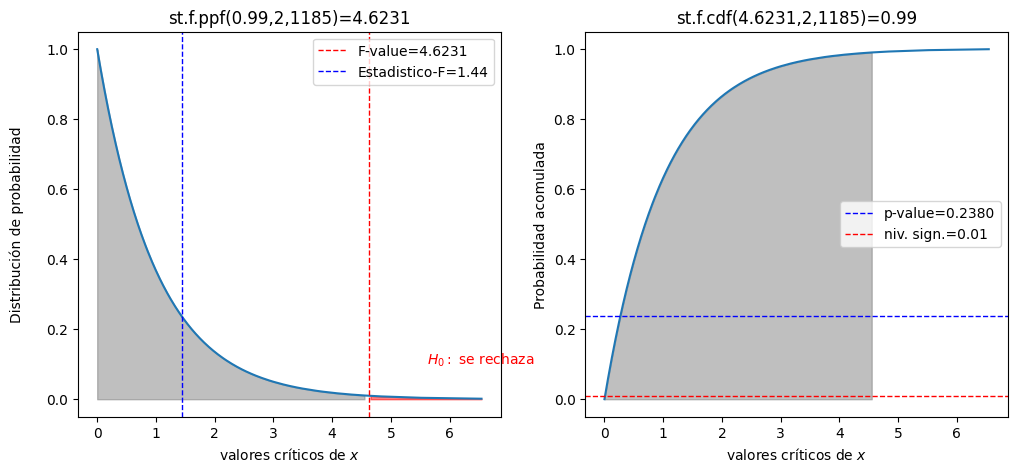

In [ ]:
# @title
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

##   Grados de libertad
gl1=nu1
gl2=nu2
##   Nivel de significancia alpha  en la Distribución-F
#alpha=0.95
signif=1-alpha
F_val=st.f.ppf(alpha,gl1,gl2)

#   Muestras
muestra1=np.random.chisquare(gl1, size=1000)
muestra2=np.random.chisquare(gl2, size=1000)

#   Estadistico-F: calculamos el estadistico-F
f_value=(muestra1/gl1)/(muestra2/gl2)
#   Ordenamos (sort) el estadistico-F para graficar
f_value=np.sort(f_value)

#   crea la curva normal
curvaPDF=st.f.pdf(f_value,gl1,gl2)
curvaCDF=st.f.cdf(f_value,gl1,gl2)


# Graficando las distribuciones #
plt.figure(figsize = (12,5))
#############################################################
#                            (a)
#############################################################

#     definimos un valor supremo en x (para la grafica)
#xsup=9

plt.subplot(1,2,1)
#   Gráfica de curva PDF
plt.plot(f_value,curvaPDF)
#   Rango de rechazo de H_0
plt.fill_between(f_value,curvaPDF, where=f_value<F_val,color='gray',alpha=.5)
plt.fill_between(f_value,curvaPDF, where=f_value>F_val,color='red',alpha=.5)

#     texto H0
plt.text(F_val+1,.1, r'$H_0:$ se rechaza',c='r',fontsize=10)

plt.axvline(F_val, color = "r", linewidth = 1, linestyle = "dashed",label=f'F-value={F_val:.4f}')
plt.axvline(F_estR, color = "b", linewidth = 1, linestyle = "dashed",label=f'Estadistico-F={F_estR:.2f}')

plt.title(f'st.f.ppf({alpha:.2f},{gl1:.0f},{gl2:.0f})={F_val:.4f}',fontsize=12)
plt.xlabel('valores críticos de $x$')
plt.ylabel('Distribución de probabilidad\n ')
#plt.xlim(0,xsup)
plt.legend()

plt.savefig('curvaPDF.jpg', dpi=300, bbox_inches='tight')

#############################################################
#                            (b)
#############################################################
plt.subplot(1,2,2)
#   Gráfica de la curva CDF
plt.plot(f_value,curvaCDF)
#   Rango de rechazo de H_0
plt.fill_between(f_value,curvaCDF, where=f_value<F_val,color='gray',alpha=.5)
plt.axhline(p_value, color = "b", linewidth = 1, linestyle = "dashed",label=f'p-value={p_value:.4f}');
plt.axhline(signif, color = "r", linewidth = 1, linestyle = "dashed",label=f'niv. sign.={signif:.2f}');

plt.title(f'st.f.cdf({F_val:.4f},{gl1:.0f},{gl2:.0f})={alpha:.2f}',fontsize=12)
plt.xlabel('valores críticos de $x$')
plt.ylabel('Probabilidad acomulada')
#plt.xlim(0,xsup)
plt.savefig('curvaCDF.jpg', dpi=300, bbox_inches='tight')
plt.legend()

plt.show()


## **Resultados del modelo no restringido y modelo restringido**

In [ ]:
from statsmodels.iolib.summary2 import summary_col

print(summary_col([reg_nr,reg_r2],stars=True,float_format='%0.3f',
                  model_names=['Modelo nr', 'Modelo r'],
                  info_dict={'N':lambda x: "{0:d}".format(int(x.nobs)),
                             'R2':lambda x: "{:.2f}".format(x.rsquared)}))




               Modelo nr   Modelo r 
------------------------------------
Intercept      114.524*** 115.470***
               (3.728)    (1.656)   
cigs           -0.596***  -0.598*** 
               (0.110)    (0.109)   
parity         1.788***   1.832***  
               (0.659)    (0.658)   
faminc         0.056      0.067**   
               (0.037)    (0.032)   
motheduc       -0.370               
               (0.320)              
fatheduc       0.472*               
               (0.283)              
R-squared      0.039      0.036     
R-squared Adj. 0.035      0.034     
N              1191       1191      
R2             0.04       0.04      
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


# **Conclusión:**

